In [1]:
import qutip as qt
from qutip import tensor, basis, qeye
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.optimize import curve_fit
from itertools import product
from quantum_logical.gate_extender import Gate_extender, Convert_levels
from quantum_logical.trotterization import Trotterization
from quantum_logical.cnot_gate_creation import cnot

In [2]:
import numpy as np
import csv
import os 

folder_path = r'C:\Users\girgi\Desktop\Github\quantum_logical\src\notebooks\Repetition_erasure_experiment'
os.chdir(folder_path)

# plot one (showing on a one cycle basis for a scan over t1 the logical error probability as a function of physical error rate)
ideal_state = np.loadtxt('3rd_order_correction_logical_physical.csv', delimiter=',')
erasure_only_3 = np.loadtxt('3rd_order_codeword_state_erasure_only.csv', delimiter=',')
phase_only_3 = np.loadtxt('3rd_order_codeword_state_phase_only.csv', delimiter=',')
phase_only_5 = np.loadtxt('5th_order_codeword_state_phase_only.csv', delimiter=',')
erasure_only_active3 = np.loadtxt('3rd_order_codeword_state_erasure_only_no_t1.csv', delimiter=',')

erasure_only_3 = np.loadtxt('3rd_order_codeword_state_erasure_only_.csv', delimiter=',')
phase_only_3 = np.loadtxt('3rd_order_codeword_state_phase_only_.csv', delimiter=',')
# phase_only_5 = np.loadtxt('5th_order_codeword_state_phase_only_.csv', delimiter=',')

erasure_only_3 = np.loadtxt('3rd_order_states_erasure.csv', delimiter=',')
phase_only_3 = np.loadtxt('3rd_order_states_phase_3.csv', delimiter=',')
phase_only_5 = np.loadtxt('3rd_order_states_phase_5.csv', delimiter=',')
# phase_only_3 = np.loadtxt('3rd_order_states_phase_3_no_t1.csv', delimiter=',')
# phase_only_5 = np.loadtxt('3rd_order_states_phase_5_no_t1.csv', delimiter=',')

order01 = np.loadtxt('3rd_order_01_t1_100.csv', delimiter=',')
# order11 = np.loadtxt('3rd_order_11_t1_100.csv', delimiter=',')
order011 = np.loadtxt('3rd_order_011_t1_100.csv', delimiter=',')
order001 = np.loadtxt('3rd_order_001_t1_100.csv', delimiter=',')
order0001 = np.loadtxt('3rd_order_0001_t1_100.csv', delimiter=',')


useful experiments 

Text(0, 0.5, 'Logical error probability')

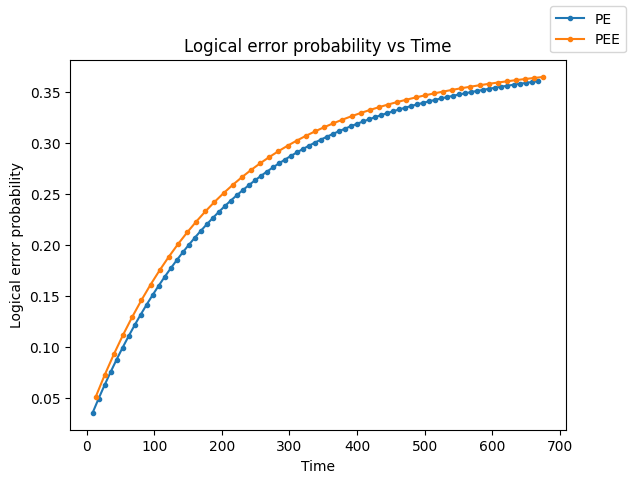

In [3]:
fig, ax = plt.subplots()
ax.plot(order01[2], order01[1], marker=".", label="PE")
# ax.plot(order11[2], order11[1], marker=".", label="11")
ax.plot(order011[2], order011[1], marker=".", label="PEE")
# ax.plot(order001[2], order001[1], marker=".", label="001")
# ax.plot(order0001[2], order0001[1], marker=".", label="0001")

fig.legend()
ax.set_title("Logical error probability vs Time")
ax.set_xlabel("Time")
ax.set_ylabel("Logical error probability")

useless experiments

Text(0, 0.5, 'Logical error probability')

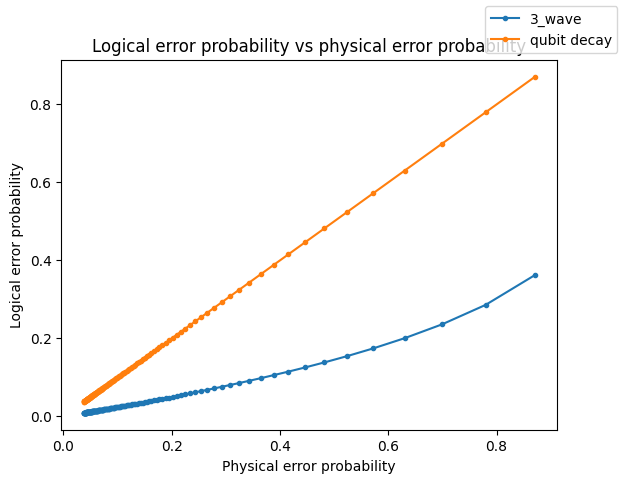

In [4]:
fig, ax = plt.subplots()
ax.plot(ideal_state[0], ideal_state[1], marker=".", label="3_wave")
ax.plot(ideal_state[0], ideal_state[0], marker=".", label="qubit decay")

fig.legend()
ax.set_title("Logical error probability vs physical error probability")
ax.set_xlabel("Physical error probability")
ax.set_ylabel("Logical error probability")


Text(0, 0.5, 'Logical error probability')

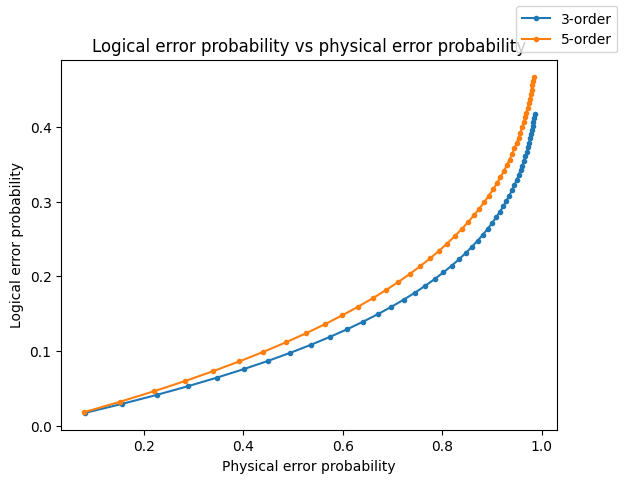

In [5]:
fig, ax = plt.subplots()
ax.plot(phase_only_3[0], phase_only_3[1], marker=".", label="3-order")
ax.plot(phase_only_5[0], phase_only_5[1], marker=".", label="5-order")

fig.legend()
ax.set_title("Logical error probability vs physical error probability")
ax.set_xlabel("Physical error probability")
ax.set_ylabel("Logical error probability")

Text(0, 0.5, 'Logical error probability')

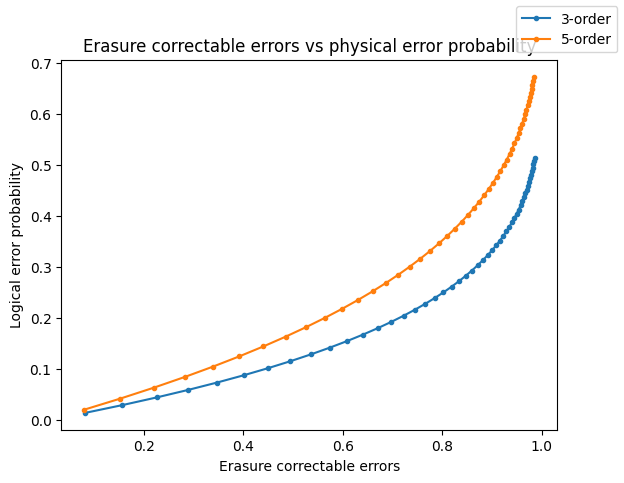

In [6]:
fig, ax = plt.subplots()
ax.plot(phase_only_3[0], phase_only_3[3], marker=".", label="3-order")
ax.plot(phase_only_5[0], phase_only_5[3], marker=".", label="5-order")

fig.legend()
ax.set_title("Erasure correctable errors vs physical error probability")
ax.set_xlabel("Erasure correctable errors")
ax.set_ylabel("Logical error probability")

Text(0, 0.5, 'logical error rate')

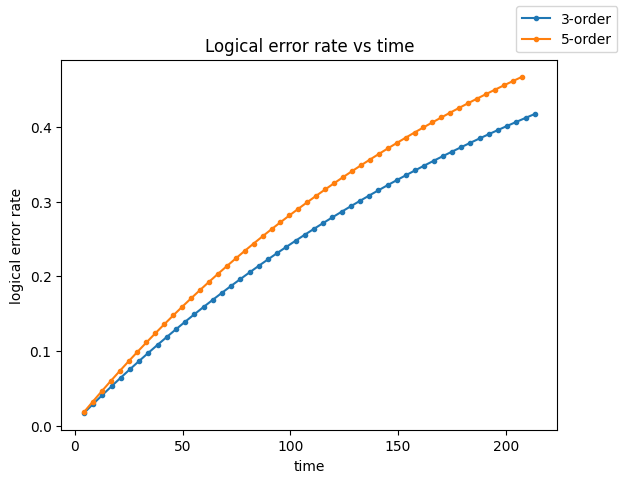

In [7]:
fig, ax = plt.subplots()
ax.plot(phase_only_3[2], phase_only_3[1], marker=".", label="3-order")
ax.plot(phase_only_5[2], phase_only_5[1], marker=".", label="5-order")

fig.legend()
ax.set_title("Logical error rate vs time")
ax.set_xlabel("time")
ax.set_ylabel("logical error rate")

Text(0, 0.5, 'Phase correctable errors')

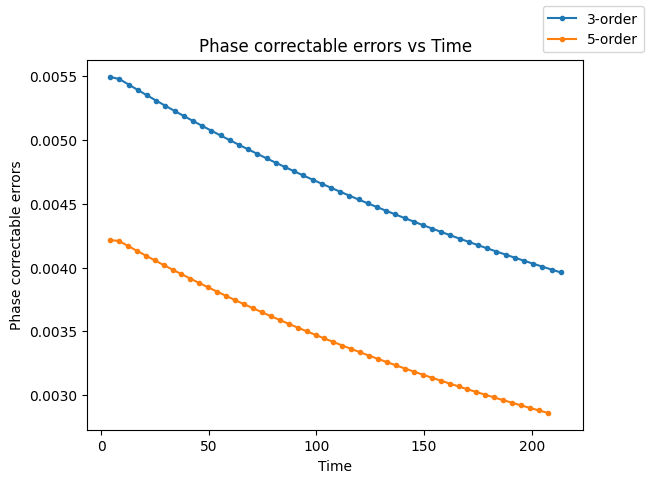

In [8]:
fig, ax = plt.subplots()
ax.plot(phase_only_3[2], phase_only_3[4], marker=".", label="3-order")
ax.plot(phase_only_5[2], phase_only_5[4], marker=".", label="5-order")

fig.legend()
ax.set_title("Phase correctable errors vs Time")
ax.set_xlabel("Time")
ax.set_ylabel("Phase correctable errors")

Text(0, 0.5, 'Correctable errors')

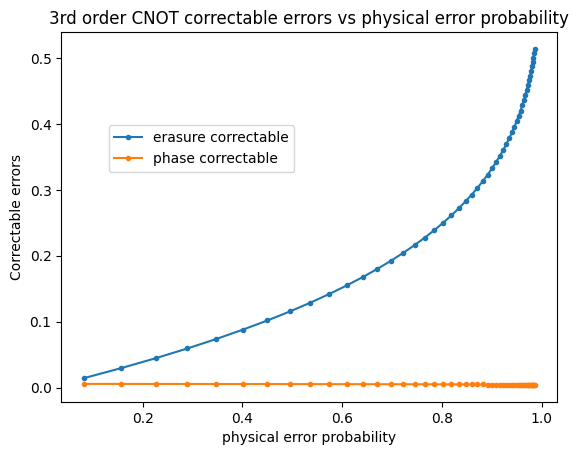

In [9]:
fig, ax = plt.subplots()
ax.plot(phase_only_3[0], phase_only_3[3], marker=".", label="erasure correctable")
ax.plot(phase_only_3[0], phase_only_3[4], marker=".", label="phase correctable")
# ax.plot(erasure_only_active3[0], erasure_only_active3[3], marker=".", label="phase correctable no t1")


fig.legend(loc="upper right", bbox_to_anchor=(.5, .7))
ax.set_title("3rd order CNOT correctable errors vs physical error probability")
ax.set_xlabel("physical error probability")
ax.set_ylabel("Correctable errors")

In [10]:
phase_only_3[3][0]

0.014228187386923191

In [11]:
erasure_only_3[2][0]

4.0

Text(0, 0.5, 'Correctable erasure errors')

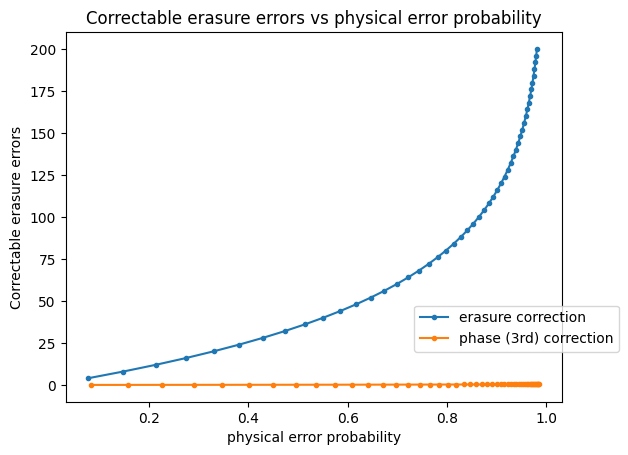

In [12]:
fig, ax = plt.subplots()
ax.plot(erasure_only_3[0], erasure_only_3[2], marker=".", label="erasure correction")
ax.plot(phase_only_3[0], phase_only_3[3], marker=".", label="phase (3rd) correction")
# ax.plot(phase_only_5[0], phase_only_5[3], marker=".", label="phase (5th) correction")

# ax.plot(erasure_only_active3[0], erasure_only_active3[3], marker=".", label="phase correctable no t1")


fig.legend(loc="lower right", bbox_to_anchor=(1, .2))
ax.set_title("Correctable erasure errors vs physical error probability")
ax.set_xlabel("physical error probability")
ax.set_ylabel("Correctable erasure errors")

Text(0, 0.5, 'Correctable phase errors')

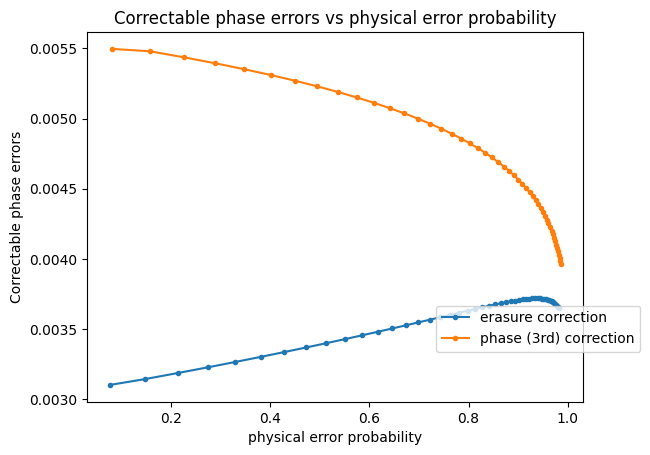

In [13]:
fig, ax = plt.subplots()
ax.plot(erasure_only_3[0], erasure_only_3[3], marker=".", label="erasure correction")
ax.plot(phase_only_3[0], phase_only_3[4], marker=".", label="phase (3rd) correction")
# ax.plot(phase_only_5[0], phase_only_5[4], marker=".", label="phase (5th) correction")

# ax.plot(erasure_only_active3[0], erasure_only_active3[3], marker=".", label="phase correctable no t1")


fig.legend(loc="lower right", bbox_to_anchor=(1, .2))

ax.set_title("Correctable phase errors vs physical error probability")
ax.set_xlabel("physical error probability")
ax.set_ylabel("Correctable phase errors")

Text(0, 0.5, 'Expectation value totals')

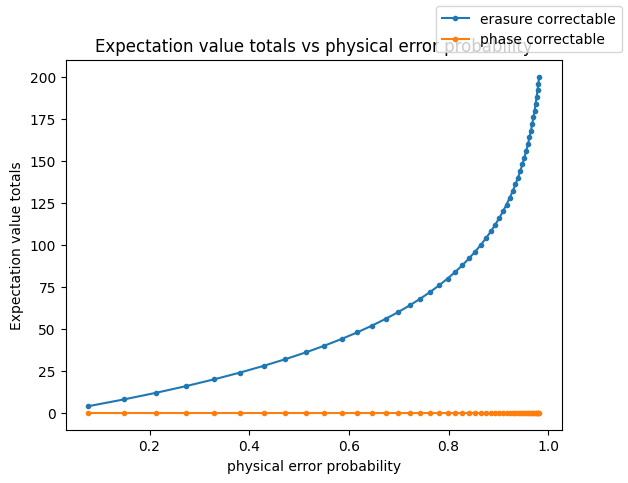

In [14]:
fig, ax = plt.subplots()
ax.plot(erasure_only_3[0], erasure_only_3[2], marker=".", label="erasure correctable")
ax.plot(erasure_only_3[0], erasure_only_3[3], marker=".", label="phase correctable")
# ax.plot(erasure_only_active3[0], erasure_only_active3[3], marker=".", label="phase correctable no t1")


fig.legend()
ax.set_title("Expectation value totals vs physical error probability")
ax.set_xlabel("physical error probability")
ax.set_ylabel("Expectation value totals")

Text(0, 0.5, 'Logical error probability 3-wave')

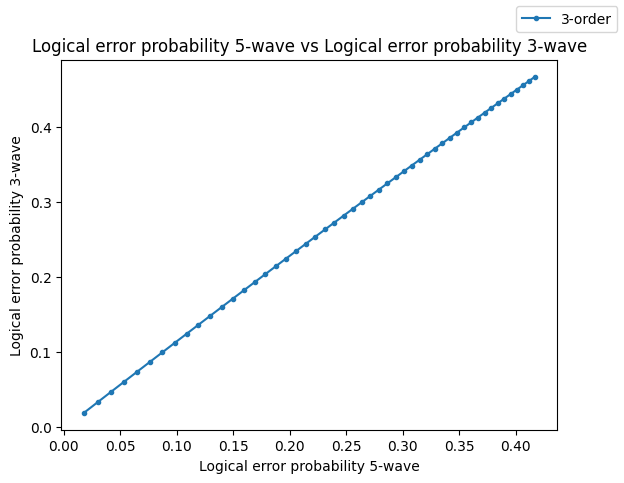

: 

In [15]:
fig, ax = plt.subplots()
ax.plot(phase_only_3[1], phase_only_5[1], marker=".", label="3-order")

fig.legend()
ax.set_title("Logical error probability 5-wave vs Logical error probability 3-wave")
ax.set_xlabel("Logical error probability 5-wave")
ax.set_ylabel("Logical error probability 3-wave")